## Introduction - Image Classification Challenge

In this team-based challenge, we will develop a deep learning model to classify images into 7 distinct dinosaur species. This project is part of the 'Artificial Intelligence' course at Thomas More, and focuses on applying TensorFlow/Keras for image classification.

# Challenge Details:

**Objective**: Build a deep learning model for accurate dinosaur image classification.                                                                             
**Steps**: Perform exploratory data analysis (EDA) and data cleaning before training the model. Get ready to dive into the world of dinos and deep learning!

## Team Members

Zeeshan Mehmood

Muhammad Zubair

Ehtisham Shaffiqe

## Import Libraries

The following libraries and modules are imported to support data preprocessing, model building, training, evaluation, and submission:

- `os`, `numpy`, `pandas`: Standard Python libraries for file handling, numerical operations, and tabular data processing.
- `matplotlib.pyplot`: Used to plot graphs like training loss and accuracy curves.
- `tensorflow`, `tensorflow.keras`: TensorFlow is the main deep learning framework used; `keras` is its high-level API.
- `tensorflow.keras.applications`: Includes pre-trained models like EfficientNet, VGG16, MobileNetV2, and DenseNet121.
- Preprocessing functions (`preprocess_input`) specific to each architecture are imported and aliased for clarity.
- `EarlyStopping`, `ModelCheckpoint`, `ReduceLROnPlateau`: Training callbacks for improving convergence and preventing overfitting.
- `sklearn.metrics`: Used for evaluation via confusion matrix.

In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, VGG16, MobileNetV2, DenseNet121, EfficientNetB5
from tensorflow.keras.applications import EfficientNetB7, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm import tqdm  # Import tqdm for progress bar
from tensorflow.keras import regularizers

## Configuration

The following constants are defined to set up the image classification training pipeline:

- `BATCH_SIZE = 32`: Number of samples processed in one forward/backward pass. 32 is a good default — balances speed and stability.
- `IMG_HEIGHT = 224`, `IMG_WIDTH = 224`: Input image dimensions used across all models.
- `SEED = 123`: Seed for reproducibility (shuffling, data splitting).
- `EPOCHS = 20`: Maximum number of epochs to train each model.

These constants ensure consistency across the entire notebook, especially for reproducible experiments.

In [2]:


# Configurations
BATCH_SIZE = 32 #  defines how many samples (images) are processed at once before the model updates its weights.
IMG_HEIGHT = 224
IMG_WIDTH = 224
SEED = 123 #Using the same seed ensures that model behavior is consistent between runs
EPOCHS = 20


## Directory Setup
- `TRAIN_DIR = 'train'` and `TEST_DIR = 'test'` are the paths to the dataset folders.
  - `train/`  contain subdirectories for each class label.
  - `test/`  contain a `test/` subfolder with unlabeled images to be used for prediction and Kaggle submission.


In [3]:
# Directories
TRAIN_DIR = 'train'
TEST_DIR = 'test'

## Dataset Preparation

 Function below is responsible for loading and preparing the training and validation datasets from the directory structure on disk using TensorFlow's high-level image_dataset_from_directory() utility. It loads 80% of the images as the training set from the specified directory and automatically labels images based on subfolder names. It loads 20% of the images as the validation set using the same split and seed. 

In [4]:
def prepare_datasets(train_dir, batch_size, img_height, img_width, seed):

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.2,
        subset="training",
        seed=seed,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=0.2,
        subset="validation",
        seed=seed,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    class_names = train_ds.class_names
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(buffer_size=AUTOTUNE) # This allows the data loading to be done in parallel with model training, improving performance.
    val_ds = val_ds.prefetch(buffer_size=AUTOTUNE) #

    return train_ds, val_ds, class_names
# Prepare datasets
train_ds, val_ds, class_names = prepare_datasets(TRAIN_DIR, BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, SEED)

Found 1269 files belonging to 7 classes.
Using 1016 files for training.
Found 1269 files belonging to 7 classes.
Using 253 files for validation.


## Exploratory Data Analysis (EDA)

In this section, we analyze the distribution of images across the different dinosaur classes in the training dataset. 
Understanding class balance is crucial for building robust classification models, as significant class imbalances can negatively 
impact model performance. We visualize the number of images per class to identify any potential imbalances and guide further data
 preprocessing or augmentation strategies if needed.

Total number of classes: 7


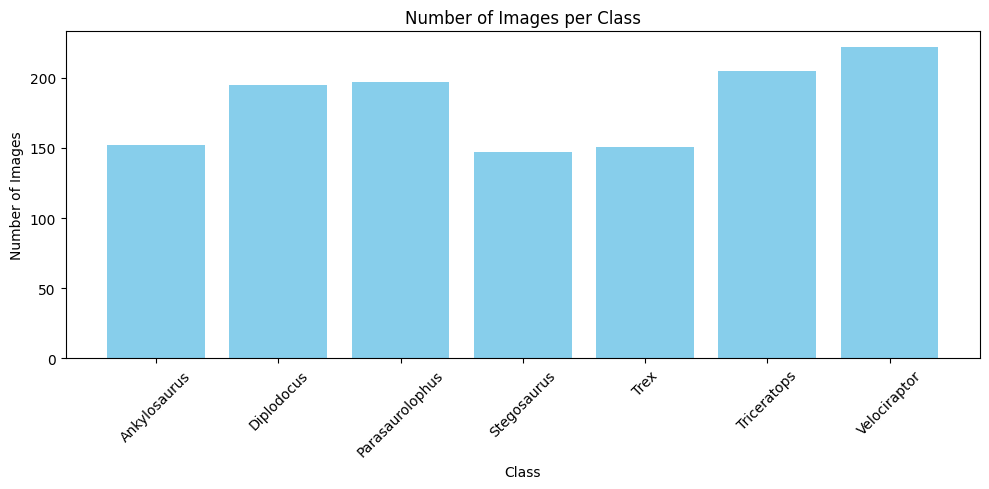

In [43]:
# Count images per class in the training directory
class_counts = {}
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = num_images

# Print total number of classes
print(f"Total number of classes: {len(class_counts)}")

# Plot number of images per class
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images per Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The following code visualizes 5 sample images from each dinosaur class in the training dataset. For each class, it displays a row of images with the class name as the title. This helps to get an overview of the image content and quality for each class, and to spot any anomalies or inconsistencies in the dataset.


Class: Ankylosaurus


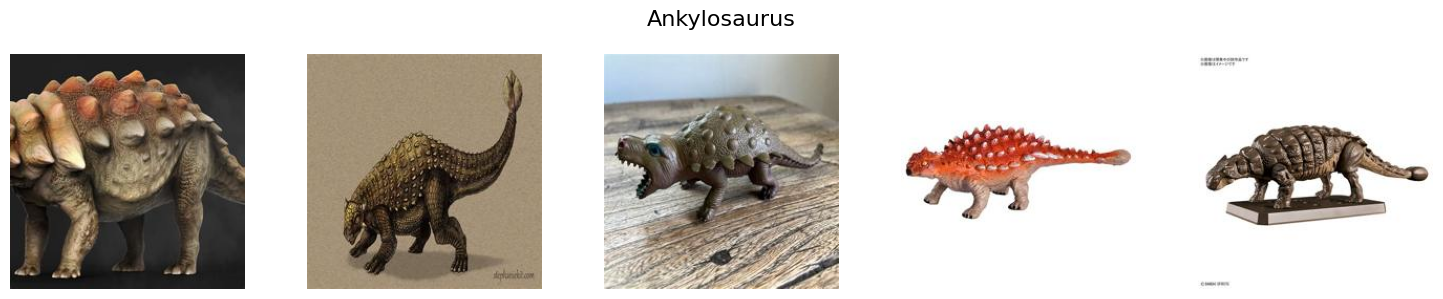

Class: Diplodocus


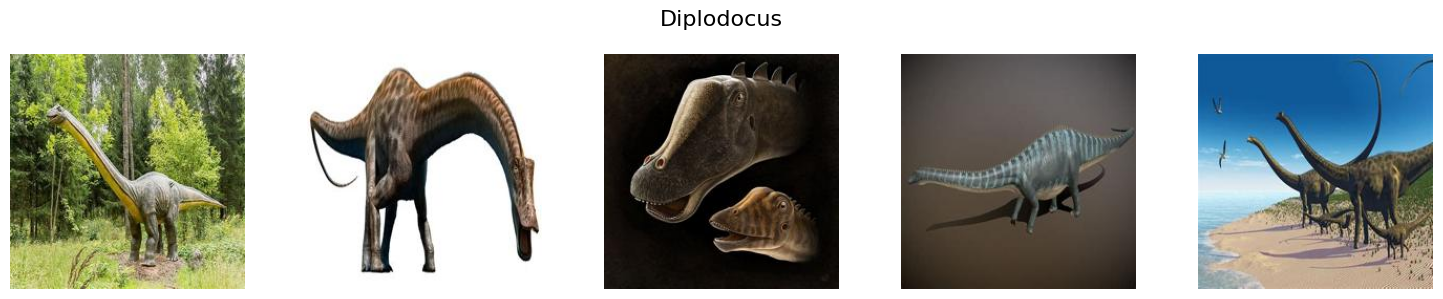

Class: Parasaurolophus


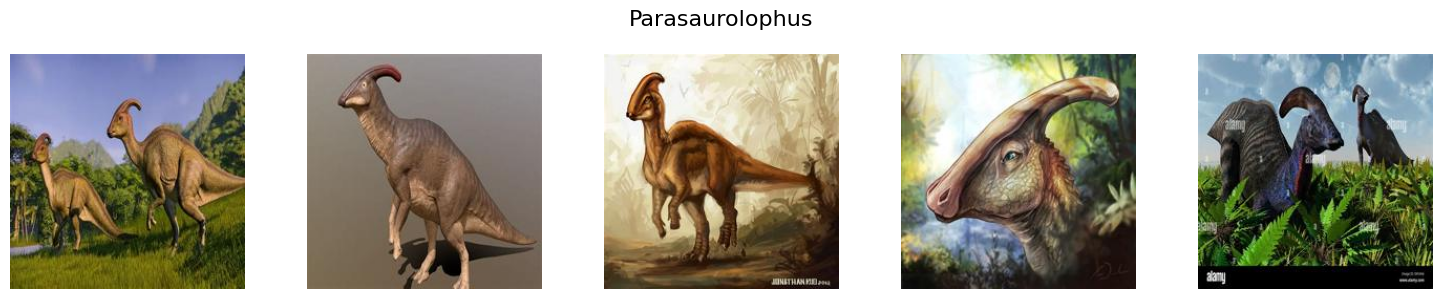

Class: Stegosaurus


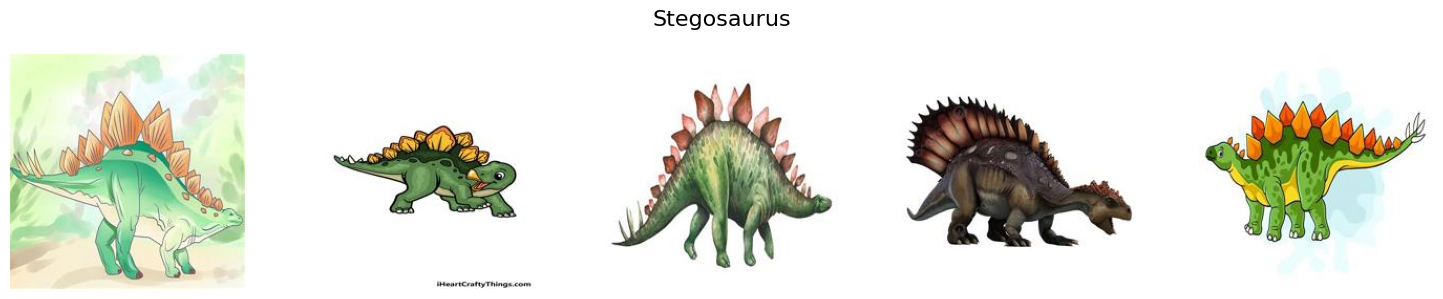

Class: Trex


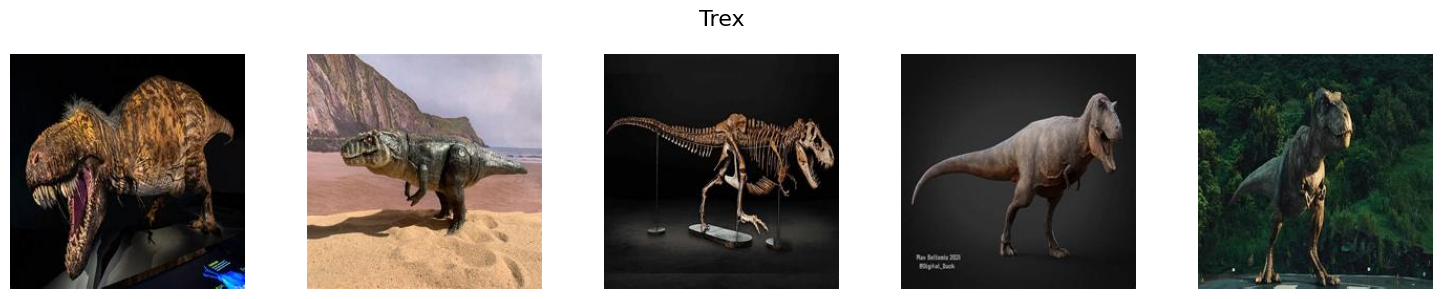

Class: Triceratops


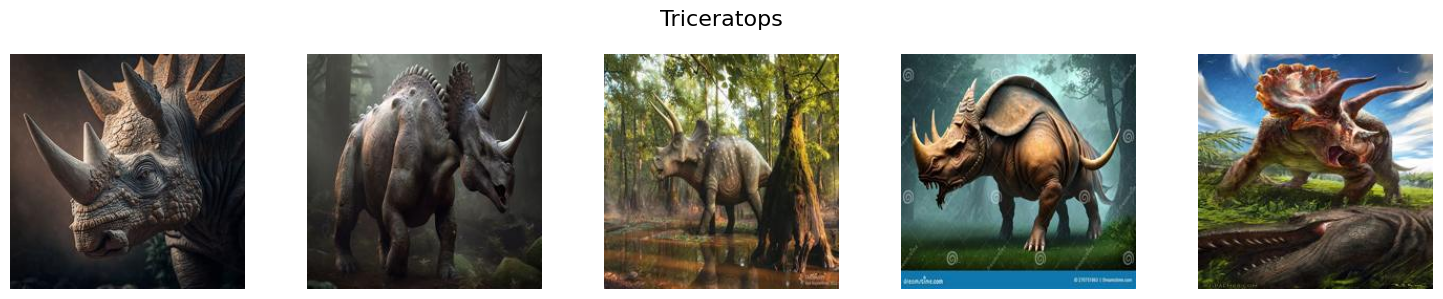

Class: Velociraptor


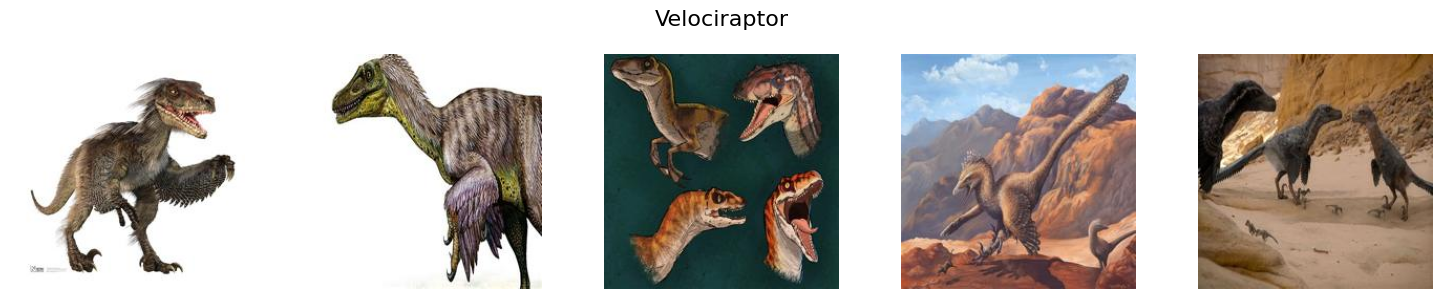

In [44]:
# Visualize 5 images per class with class name printed on top
for class_name in class_counts.keys():
    print(f"Class: {class_name}")
    class_dir = os.path.join(TRAIN_DIR, class_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for col_idx, img_file in enumerate(image_files):
        img_path = os.path.join(class_dir, img_file)
        img = plt.imread(img_path)
        axes[col_idx].imshow(img)
        axes[col_idx].axis('off')
    plt.suptitle(class_name, fontsize=16)
    plt.tight_layout()
    plt.show()


The following code iterates through one batch of images from the training dataset and visualizes the first 8 images in that batch. For each image, it displays the image along with its corresponding class name and label. This helps to quickly inspect the loaded data and verify that images and labels are correctly paired.

Shape of images batch: (32, 224, 224, 3)


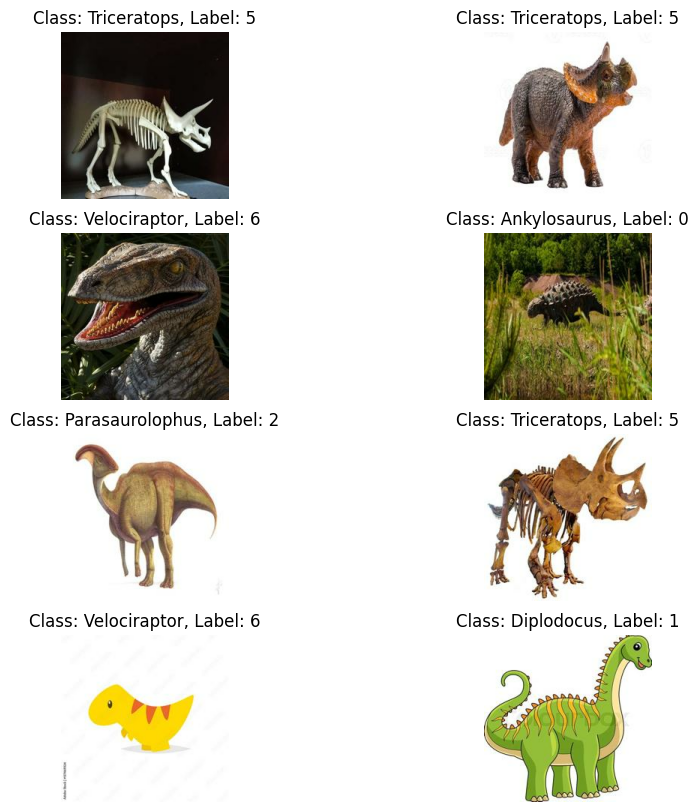

In [6]:
# Access images and labels from a tf.data.Dataset (train_ds)
for images, labels in train_ds:
    # 'images' is a batch of images with shape (batch_size, IMG_HEIGHT, IMG_WIDTH, 3)
    # 'labels' is an array of integer class indices with shape (batch_size,)

    # Get the class names (subfolder names) from the class indices
    class_names_batch = [class_names[i] for i in labels.numpy()]

    # Print the shape of the first batch of images
    print("Shape of images batch:", images.shape)

    # Visualize a sample of images along with their class names and labels
    plt.figure(figsize=(10, 10))
    for i in range(8):  # Visualize the first 8 images in the batch
        plt.subplot(4, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_name = class_names_batch[i]
        label = labels.numpy()[i]
        plt.title(f"Class: {class_name}, Label: {label}")
        plt.axis("off")
    plt.show()

    # Example: Break the loop after processing one batch
    break

Following code helps ensure consistency in your dataset by checking whether all images within each class subfolder have the same file extension (e.g., .jpg, .png, etc.).

In [22]:
# Path to the directory containing subfolders (each representing a class)
data_dir = TRAIN_DIR  # Use the existing TRAIN_DIR variable

# Get list of subfolders (classes)
classes = os.listdir(data_dir)

# Iterate over each subfolder and check file extensions
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)

    # Get list of files in the subfolder
    files = os.listdir(class_path)

    # Extract file extensions
    extensions = {os.path.splitext(file)[1] for file in files}

    # If there's only one unique extension, all images have the same format
    if len(extensions) == 1:
        print(f"All images in '{class_name}' have the same extension: {extensions.pop()}")
    else:
        print(f"Images in '{class_name}' have multiple extensions: {extensions}")

All images in 'Ankylosaurus' have the same extension: .jpg
All images in 'Diplodocus' have the same extension: .jpg
All images in 'Parasaurolophus' have the same extension: .jpg
All images in 'Stegosaurus' have the same extension: .jpg
All images in 'Trex' have the same extension: .jpg
All images in 'Triceratops' have the same extension: .jpg
All images in 'Velociraptor' have the same extension: .jpg


The following code analyzes the distribution of image dimensions (width and height) and the average RGB color values across all images in the training dataset. It uses the PIL library to open each image, records its size, and computes the mean RGB values. The results are visualized using seaborn histograms for width and height distributions, and the overall average RGB values are printed. This helps to identify inconsistencies in image sizes and color characteristics, which can inform preprocessing and augmentation strategies.

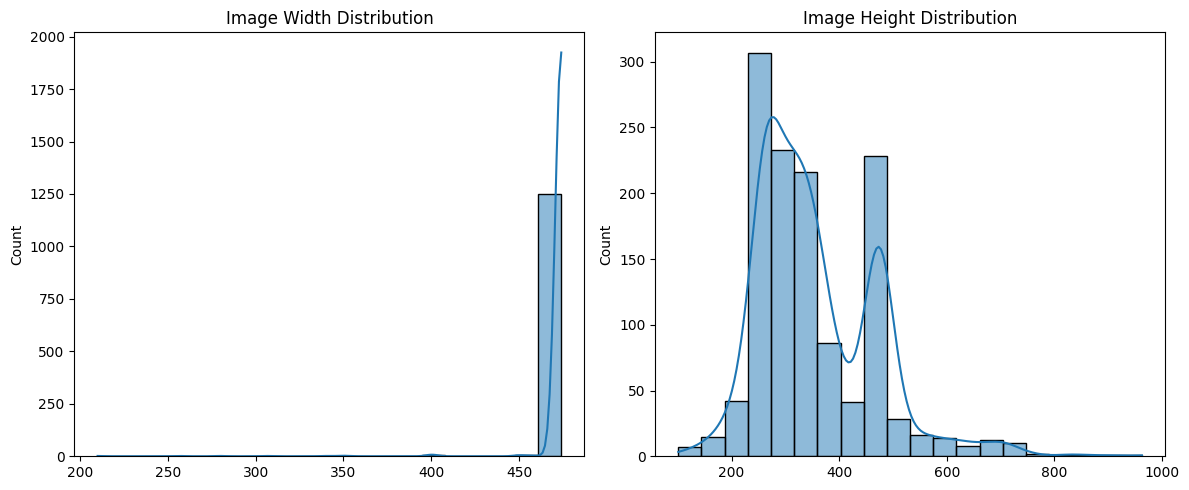

Average RGB values: [149.86039983 147.89159103 138.25236514]


In [ ]:
image_shapes = []
rgb_means = []

# Loop through classes and images
for cls in class_names:
    cls_folder = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            image_shapes.append(img.size)  # (width, height)
            rgb_means.append(np.mean(np.array(img), axis=(0, 1)))
        except Exception as e:
            print(f"Could not process: {img_path} ({e})")

# Only plot if images were found
if image_shapes:
    widths, heights = zip(*image_shapes)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(widths, kde=True, bins=20)
    plt.title("Image Width Distribution")

    plt.subplot(1, 2, 2)
    sns.histplot(heights, kde=True, bins=20)
    plt.title("Image Height Distribution")

    plt.tight_layout()
    plt.show()

    # RGB mean analysis
    rgb_means = np.array(rgb_means)
    print(f"Average RGB values: {rgb_means.mean(axis=0)}")
else:
    print("No images found to analyze.")

The following code defines a function to count the number of low-resolution images (smaller than 224x224 pixels) in each class folder of the training dataset. It then prints the total number of such images found and displays a few examples. This helps identify images that may need resizing or removal to ensure consistency in model training.

In [28]:
def count_low_res_images(folder_path, min_size=(224, 224)):
    low_res_images = []
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)
            try:
                img = Image.open(img_path).convert("RGB")
                if img.size[0] < min_size[0] or img.size[1] < min_size[1]:
                    low_res_images.append((cls, img_file, img.size))
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return low_res_images

low_res_train = count_low_res_images(TRAIN_DIR)
print(f"Found {len(low_res_train)} low-resolution training images.")
if low_res_train:
    print("Example low-res images:")
    print(low_res_train[:5])

Found 59 low-resolution training images.
Example low-res images:
[('Ankylosaurus', 'Ankylosaurus_Ankylosaurus (110).jpg', (474, 219)), ('Ankylosaurus', 'Ankylosaurus_Ankylosaurus (141).jpg', (474, 220)), ('Ankylosaurus', 'Ankylosaurus_Ankylosaurus (181).jpg', (474, 194)), ('Ankylosaurus', 'Ankylosaurus_Ankylosaurus (21).jpg', (474, 198)), ('Ankylosaurus', 'Ankylosaurus_Ankylosaurus (38).jpg', (474, 179))]


The following code resizes all images in the training and test datasets to the target size of 224x224 pixels using the PIL library. It iterates through each class folder in the training directory and each image in the test directory, resizing images that do not match the target size. The tqdm library is used to display a progress bar for each class and for the test set. This ensures that all images are consistent in size, which is required for input into deep learning models.

In [ ]:


def resize_images_in_folder(folder_path, target_size=(224, 224)):
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_file in tqdm(os.listdir(cls_path), desc=f"Resizing {cls}"):
            img_path = os.path.join(cls_path, img_file)
            try:
                img = Image.open(img_path).convert("RGB")
                if img.size != target_size:
                    img = img.resize(target_size)
                    img.save(img_path)
            except Exception as e:
                print(f"Error with {img_path}: {e}")

resize_images_in_folder(TRAIN_DIR)

def resize_test_images(test_path, target_size=(224, 224)):
    for img_file in tqdm(os.listdir(test_path), desc="Resizing test images"):
        img_path = os.path.join(test_path, img_file)
        try:
            img = Image.open(img_path).convert("RGB")
            if img.size != target_size:
                img = img.resize(target_size)
                img.save(img_path)
        except Exception as e:
            print(f"Error with {img_path}: {e}")

resize_test_images(os.path.join(TEST_DIR, 'test'))

Resizing test images: 100%|██████████| 303/303 [00:05<00:00, 53.56it/s]


## Data Augmentation

The following code defines a data augmentation pipeline using TensorFlow's Keras API. The `augmentation` sequential model applies several random transformations to the training images to improve model generalization and reduce overfitting:

- `RandomFlip("horizontal")`: Randomly flips images horizontally.
- `RandomRotation(0.1)`: Randomly rotates images by up to 10%.
- `RandomZoom(0.1)`: Randomly zooms images in or out by up to 10%.
- `RandomTranslation(0.1, 0.1)`: Randomly shifts images horizontally and vertically by up to 10%.

These augmentations are applied on-the-fly during training, helping the model learn more robust features from the data.

In [7]:
# Data augmentation
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

## CNN model from scratch

In [63]:


def build_custom_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.6),  # Increased from 0.5 to 0.6

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## Model Builder with Fine-Tuning Function

This function builds a model using a pre-trained convolutional base (like EfficientNet or DenseNet), applies Keras data augmentation, and adds custom fully-connected layers ("the head") to adapt the model for our dataset.

- If `fine_tune_at` is set, it partially unfreezes the base model's top layers to allow fine-tuning.
- The rest of the base remains frozen to retain ImageNet-learned features.

In [ ]:

# Model builder with fine-tuning option

def build_model(base_model_class, preprocess_func, input_shape, num_classes, fine_tune=False, fine_tune_at=None):
    base_model = base_model_class(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = fine_tune
    if fine_tune and fine_tune_at is not None:
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_func(x)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## Model Training, Evaluation and Visualization Function

This function trains the model using the provided training and validation datasets. It includes:
- `EarlyStopping`: stops training early if validation loss doesn’t improve.
- `ModelCheckpoint`: saves the best model based on validation loss.
- `ReduceLROnPlateau`: lowers the learning rate if progress stalls.

It also visualizes training and validation accuracy/loss per epoch. It aslo visualizes the confusion matrix

In [ ]:
# Training and evaluation

def train_and_evaluate_model(model, train_ds, val_ds, model_name, class_names):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f'{model_name}_best_model.h5', monitor='val_loss', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
    y_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

## Prepare Datasets for Training and Validation


This section loads the training images and splits them into training and validation sets (80/20).
The function also returns the class labels inferred from folder names.

In [10]:
# Prepare datasets
train_ds, val_ds, class_names = prepare_datasets(TRAIN_DIR, BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, SEED)


Found 1269 files belonging to 7 classes.
Using 1016 files for training.
Found 1269 files belonging to 7 classes.
Using 253 files for validation.


## Load Test Dataset

The test dataset (used for Kaggle submission) is loaded with `shuffle=False` to maintain file order.
File names are also extracted and sorted for use in the final submission.

In [11]:
# Test data
raw_test_paths = sorted([f for f in os.listdir(TEST_DIR + '/test') if f.endswith('.jpg')])
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=1,
    shuffle=False
)


Found 303 files belonging to 1 classes.


##  Generate Kaggle Submission Function

After prediction, this function creates a CSV file in the format: It maps image file names to their predicted class indices and saves the file for submission to Kaggle.

In [12]:
# Prediction and CSV generation
def generate_kaggle_submission(model, test_ds, class_names, model_name):
    predictions = model.predict(test_ds)
    pred_indices = [int(np.argmax(p)) for p in predictions]
    file_names = sorted([f for f in os.listdir(os.path.join(TEST_DIR, 'test')) if f.endswith('.jpg')])
    ids = [int(os.path.splitext(fname)[0]) for fname in file_names]
    df = pd.DataFrame({"id": ids, "label": pred_indices})
    df.to_csv(f"new_{model_name}.csv", index=False)
    print(f"Saved submission file: n_{model_name}.csv")


## Models to Train


The following code defines a dictionary named `models_to_test` that maps model names to their corresponding Keras application class and preprocessing function. This setup allows for easy iteration and comparison of multiple pre-trained architectures (EfficientNetB0, EfficientNetB5, MobileNetV2, DenseNet121) during training and evaluation.

In [13]:
# Models to test
models_to_test = {
    'CustomCNN': (None, None),
    'EfficientNetB0': (EfficientNetB0, efficientnet_preprocess),
    'EfficientNetB5': (EfficientNetB5, efficientnet_preprocess),
    'EfficientNetB7': (EfficientNetB7, efficientnet_preprocess), 
    'ResNet50': (ResNet50, resnet_preprocess),                    
    'MobileNetV2': (MobileNetV2, mobilenet_preprocess),
    'DenseNet121': (DenseNet121, densenet_preprocess),   
}

## Phase 1: Feature Extraction / Initial Training

This loop iterates over all the models defined in the models_to_test dictionary and performs the initial training (without fine-tuning).

Also note down that:  If model_name == 'CustomCNN', a simple CNN is built from scratch using build_custom_cnn(). No pre-trained features are used in this case.

Pre-trained Models: For other models like EfficientNetB0, MobileNetV2, etc.: build_model(...) loads a pre-trained model with frozen weights (fine_tune=False). This is the feature extraction phase — only the custom classification head is trained.

Training and Evaluation: train_and_evaluate_model() trains the model on the training set and evaluates it on the validation set. It plots loss and accuracy curves and generates a confusion matrix.

Test Predictions: generate_kaggle_submission() runs predictions on the test set and creates a Kaggle-ready CSV file.

Memory Management: tf.keras.backend.clear_session() is used to clear model memory before the next model is loaded, preventing GPU memory issues.


--- Phase 1: Training CustomCNN ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.1280 - loss: 3.7430

32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 662ms/step - accuracy: 0.1281 - loss: 3.7128 - val_accuracy: 0.1383 - val_loss: 2.1796 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.1809 - loss: 2.1591

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 777ms/step - accuracy: 0.1809 - loss: 2.1587 - val_accuracy: 0.1897 - val_loss: 2.1137 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.2155 - loss: 2.0940

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 822ms/step - accuracy: 0.2157 - loss: 2.0938 - val_accuracy: 0.1660 - val_loss: 2.0734 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.2243 - loss: 2.0469

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 779ms/step - accuracy: 0.2246 - loss: 2.0464 - val_accuracy: 0.2569 - val_loss: 2.0126 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.3205 - loss: 1.9081

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 767ms/step - accuracy: 0.3211 - loss: 1.9070 - val_accuracy: 0.2964 - val_loss: 1.9895 - learning_rate: 0.0010
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.4119 - loss: 1.6730

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 964ms/step - accuracy: 0.4122 - loss: 1.6725 - val_accuracy: 0.3636 - val_loss: 1.9533 - learning_rate: 0.0010
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 831ms/step - accuracy: 0.5103 - loss: 1.4814 - val_accuracy: 0.3636 - val_loss: 1.9810 - learning_rate: 0.0010
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 789ms/step - accuracy: 0.5655 - loss: 1.2895 - val_accuracy: 0.3597 - val_loss: 2.0192 - learning_rate: 0.0010
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 786ms/step - accuracy: 0.6933 - loss: 1.0529 - val_accuracy: 0.3676 - val_loss: 2.0833 - learning_rate: 2.0000e-04


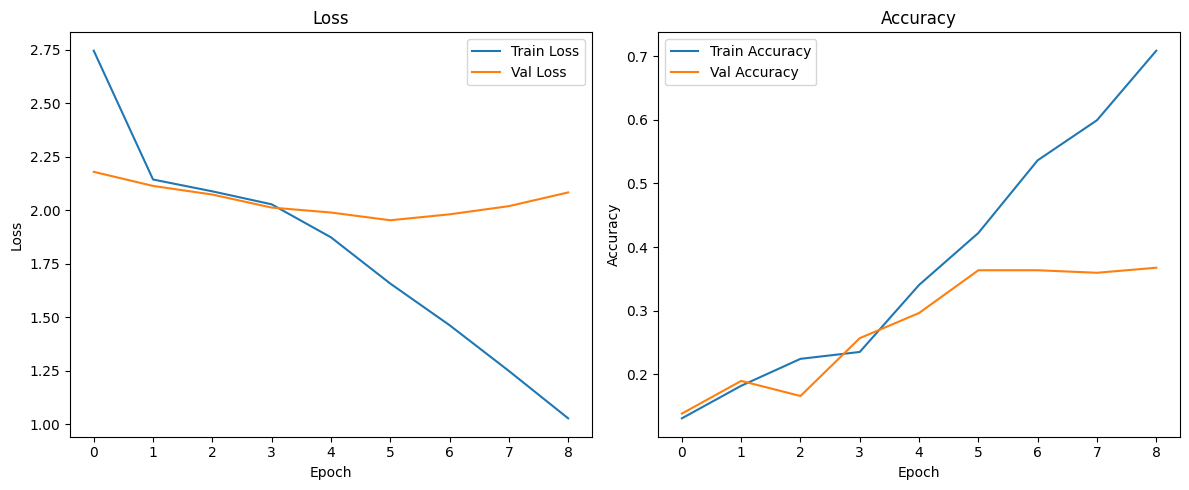

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step


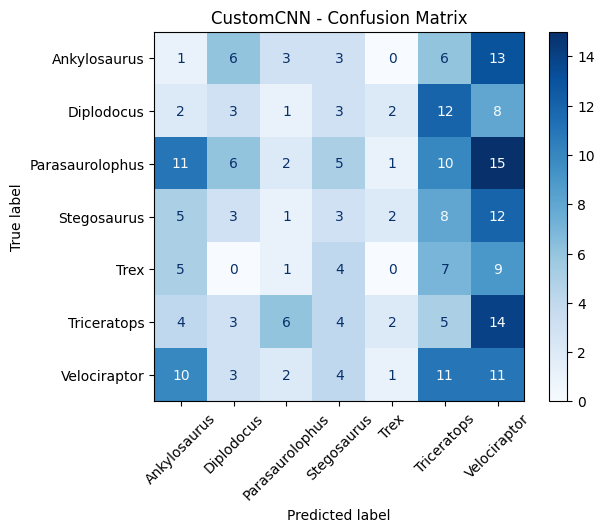

303/303 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step
Saved submission file: n_CustomCNN.csv

--- Phase 1: Training EfficientNetB0 ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.2749 - loss: 1.8019

32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 810ms/step - accuracy: 0.2787 - loss: 1.7961 - val_accuracy: 0.6957 - val_loss: 1.1019 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.6772 - loss: 1.0849

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 809ms/step - accuracy: 0.6777 - loss: 1.0829 - val_accuracy: 0.7628 - val_loss: 0.7830 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.7597 - loss: 0.8194

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 819ms/step - accuracy: 0.7598 - loss: 0.8188 - val_accuracy: 0.8142 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.8095 - loss: 0.6937

32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 881ms/step - accuracy: 0.8092 - loss: 0.6936 - val_accuracy: 0.8221 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.8161 - loss: 0.6210

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 799ms/step - accuracy: 0.9088 - loss: 0.3420 - val_accuracy: 0.8617 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9152 - loss: 0.3250

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 814ms/step - accuracy: 0.9148 - loss: 0.3256 - val_accuracy: 0.8656 - val_loss: 0.3769 - learning_rate: 0.0010
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9126 - loss: 0.3390

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 781ms/step - accuracy: 0.9125 - loss: 0.3388 - val_accuracy: 0.8696 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 788ms/step - accuracy: 0.9147 - loss: 0.3116 - val_accuracy: 0.8735 - val_loss: 0.3794 - learning_rate: 0.0010
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 974ms/step - accuracy: 0.9111 - loss: 0.3043 - val_accuracy: 0.8735 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9367 - loss: 0.2624

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 816ms/step - accuracy: 0.9362 - loss: 0.2633 - val_accuracy: 0.8735 - val_loss: 0.3718 - learning_rate: 2.0000e-04
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9237 - loss: 0.2789

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 825ms/step - accuracy: 0.9239 - loss: 0.2787 - val_accuracy: 0.8735 - val_loss: 0.3642 - learning_rate: 2.0000e-04


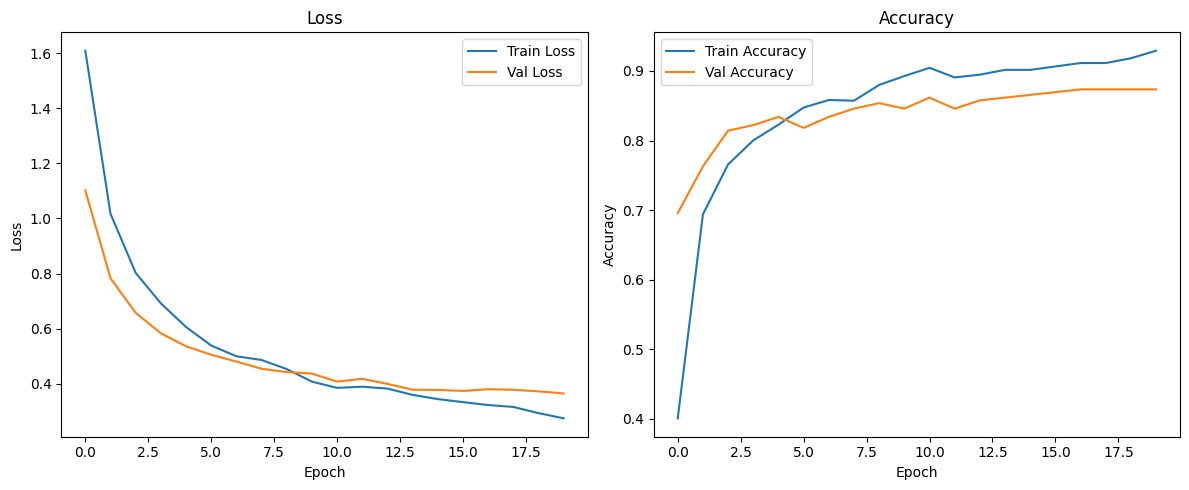

8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 


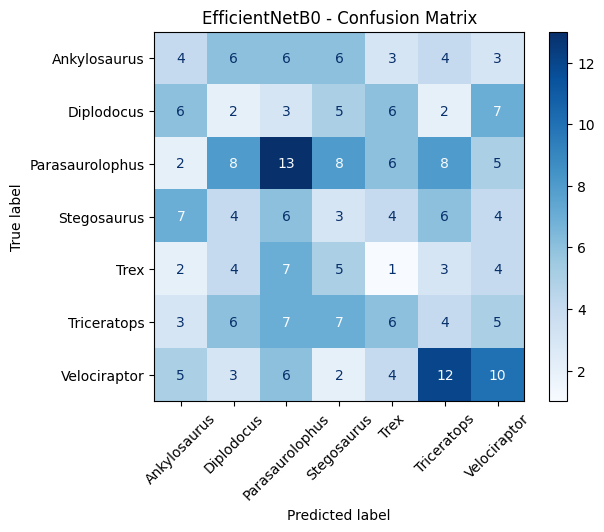

303/303 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step
Saved submission file: n_EfficientNetB0.csv

--- Phase 1: Training EfficientNetB5 ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2965 - loss: 1.7998

32/32 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.3003 - loss: 1.7937 - val_accuracy: 0.6601 - val_loss: 1.1705 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6548 - loss: 1.1477

32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.6555 - loss: 1.1458 - val_accuracy: 0.7510 - val_loss: 0.8758 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7565 - loss: 0.8783

32/32 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.7562 - loss: 0.8780 - val_accuracy: 0.7945 - val_loss: 0.7338 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7924 - loss: 0.7501

32/32 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.7919 - loss: 0.7506 - val_accuracy: 0.8340 - val_loss: 0.6400 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7880 - loss: 0.6954

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.8969 - loss: 0.3898 - val_accuracy: 0.8696 - val_loss: 0.4057 - learning_rate: 0.0010
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9040 - loss: 0.3541

32/32 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.9036 - loss: 0.3546 - val_accuracy: 0.8814 - val_loss: 0.4005 - learning_rate: 0.0010
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9014 - loss: 0.3619

32/32 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.9014 - loss: 0.3619 - val_accuracy: 0.8854 - val_loss: 0.3873 - learning_rate: 0.0010
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8830 - loss: 0.3730

32/32 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8832 - loss: 0.3727 - val_accuracy: 0.8854 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9098 - loss: 0.3419

32/32 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.9100 - loss: 0.3416 - val_accuracy: 0.8814 - val_loss: 0.3780 - learning_rate: 0.0010


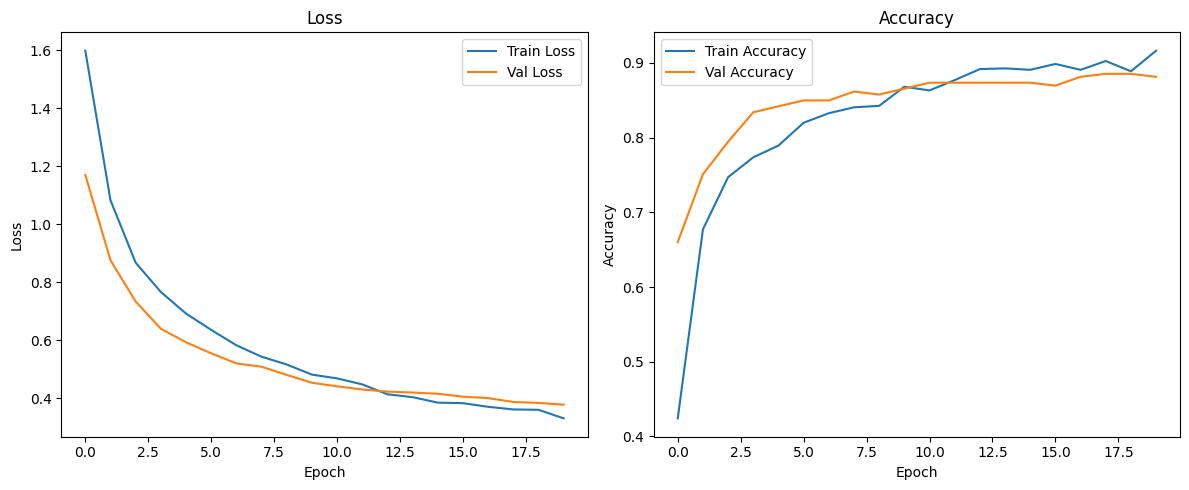

8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step


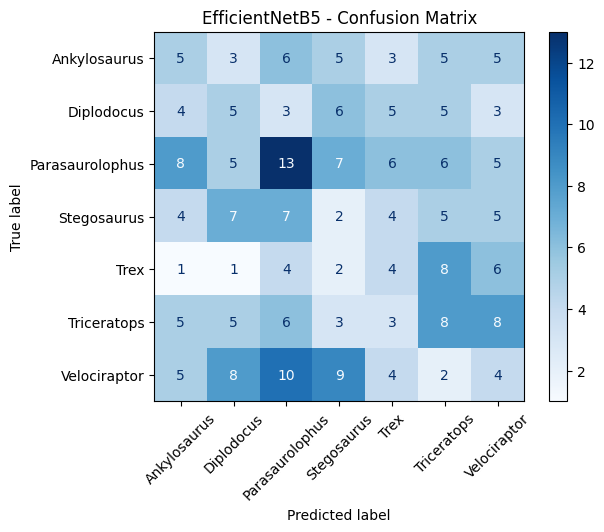

303/303 ━━━━━━━━━━━━━━━━━━━━ 48s 158ms/step
Saved submission file: n_EfficientNetB5.csv

--- Phase 1: Training EfficientNetB7 ---
258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3176 - loss: 1.7610

32/32 ━━━━━━━━━━━━━━━━━━━━ 224s 6s/step - accuracy: 0.3214 - loss: 1.7550 - val_accuracy: 0.6126 - val_loss: 1.1361 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6952 - loss: 1.0679

32/32 ━━━━━━━━━━━━━━━━━━━━ 179s 6s/step - accuracy: 0.6953 - loss: 1.0666 - val_accuracy: 0.7194 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7610 - loss: 0.8331

32/32 ━━━━━━━━━━━━━━━━━━━━ 248s 8s/step - accuracy: 0.7610 - loss: 0.8328 - val_accuracy: 0.7510 - val_loss: 0.7585 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8042 - loss: 0.6889

32/32 ━━━━━━━━━━━━━━━━━━━━ 262s 8s/step - accuracy: 0.8038 - loss: 0.6894 - val_accuracy: 0.7984 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8266 - loss: 0.6218

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.8955 - loss: 0.3386 - val_accuracy: 0.8696 - val_loss: 0.4165 - learning_rate: 0.0010
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9263 - loss: 0.3276

32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9260 - loss: 0.3282 - val_accuracy: 0.8775 - val_loss: 0.4156 - learning_rate: 0.0010
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9151 - loss: 0.3095

32/32 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.9148 - loss: 0.3103 - val_accuracy: 0.8775 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8985 - loss: 0.3514

32/32 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.8988 - loss: 0.3506 - val_accuracy: 0.8854 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9137 - loss: 0.3177

32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9139 - loss: 0.3172 - val_accuracy: 0.8854 - val_loss: 0.3871 - learning_rate: 0.0010


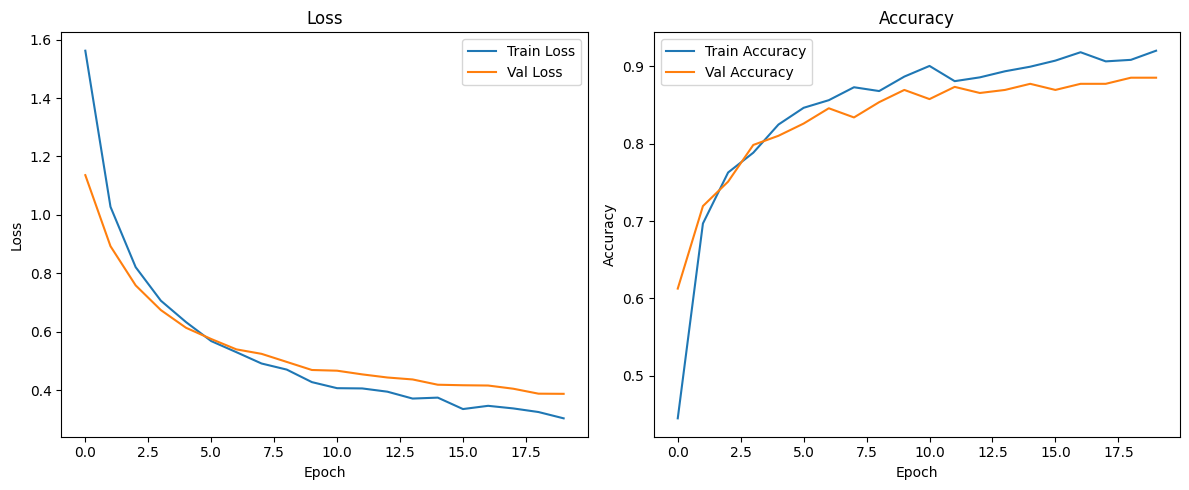

8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step


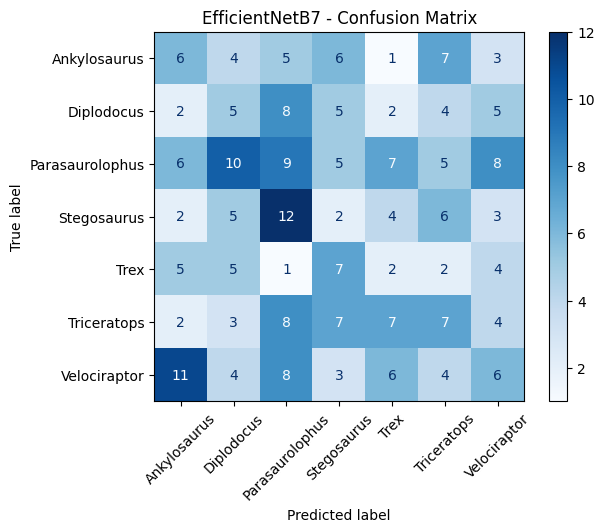

303/303 ━━━━━━━━━━━━━━━━━━━━ 68s 224ms/step
Saved submission file: n_EfficientNetB7.csv

--- Phase 1: Training ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2476 - loss: 2.1534

32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2504 - loss: 2.1425 - val_accuracy: 0.6364 - val_loss: 0.9992 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6148 - loss: 1.0502

32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6161 - loss: 1.0481 - val_accuracy: 0.7233 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7195 - loss: 0.8142

32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7203 - loss: 0.8125 - val_accuracy: 0.7945 - val_loss: 0.5901 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7763 - loss: 0.6442

32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7767 - loss: 0.6433 - val_accuracy: 0.8103 - val_loss: 0.5491 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8044 - loss: 0.5414

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8952 - loss: 0.3163 - val_accuracy: 0.8775 - val_loss: 0.3913 - learning_rate: 2.0000e-04
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8822 - loss: 0.3090 - val_accuracy: 0.8656 - val_loss: 0.4040 - learning_rate: 2.0000e-04
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9077 - loss: 0.3086

32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9075 - loss: 0.3089 - val_accuracy: 0.8696 - val_loss: 0.3848 - learning_rate: 2.0000e-04
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9079 - loss: 0.2991

32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9080 - loss: 0.2990 - val_accuracy: 0.8893 - val_loss: 0.3836 - learning_rate: 2.0000e-04
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9094 - loss: 0.2867 - val_accuracy: 0.8656 - val_loss: 0.3915 - learning_rate: 2.0000e-04
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9167 - loss: 0.2997

32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9167 - loss: 0.2994 - val_accuracy: 0.8775 - val_loss: 0.3791 - learning_rate: 2.0000e-04
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8958 - loss: 0.3152 - val_accuracy: 0.8893 - val_loss: 0.3793 - learning_rate: 2.0000e-04
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9206 - loss: 0.2673 - val_accuracy: 0.8656 - val_loss: 0.3806 - learning_rate: 2.0000e-04
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9231 - loss: 0.2738

32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9232 - loss: 0.2737 - val_accuracy: 0.8775 - val_loss: 0.3772 - learning_rate: 4.0000e-05
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9244 - loss: 0.2731 - val_accuracy: 0.8814 - val_loss: 0.3774 - learning_rate: 4.0000e-05


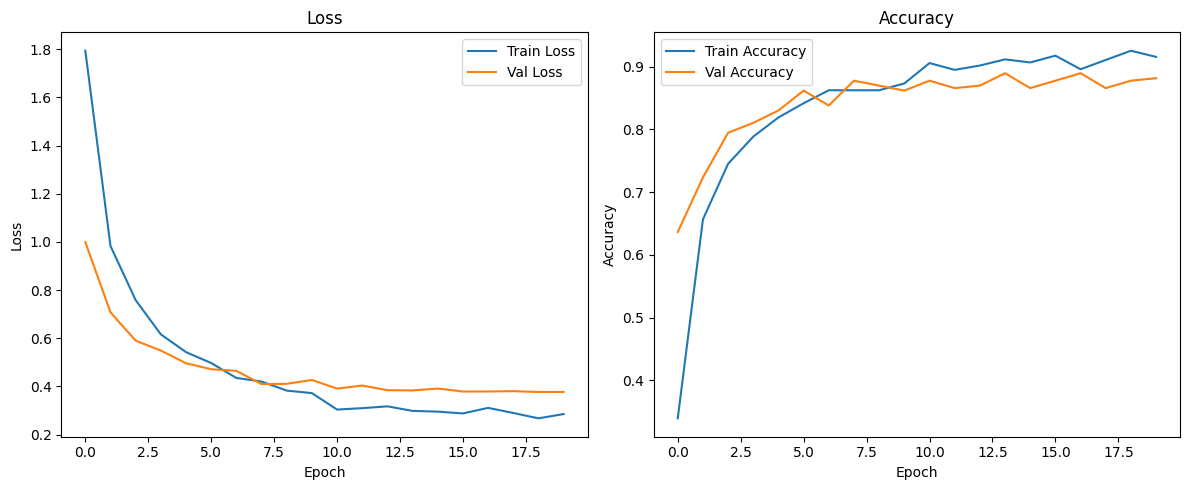

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


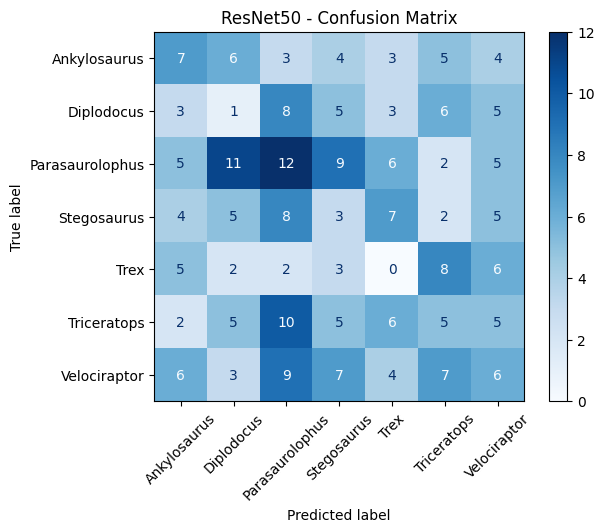

303/303 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step
Saved submission file: n_ResNet50.csv

--- Phase 1: Training MobileNetV2 ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1895 - loss: 2.1769

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - accuracy: 0.1922 - loss: 2.1688 - val_accuracy: 0.4822 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.5370 - loss: 1.3155

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 461ms/step - accuracy: 0.5381 - loss: 1.3122 - val_accuracy: 0.6680 - val_loss: 0.9587 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.6359 - loss: 1.0330

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 449ms/step - accuracy: 0.6369 - loss: 1.0306 - val_accuracy: 0.7194 - val_loss: 0.7803 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7333 - loss: 0.7912

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.7336 - loss: 0.7909 - val_accuracy: 0.7708 - val_loss: 0.6858 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.7775 - loss: 0.7059

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 477ms/step - accuracy: 0.8206 - loss: 0.5399 - val_accuracy: 0.8340 - val_loss: 0.5243 - learning_rate: 0.0010
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 446ms/step - accuracy: 0.8357 - loss: 0.4901 - val_accuracy: 0.8182 - val_loss: 0.5268 - learning_rate: 0.0010
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8370 - loss: 0.4624

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 449ms/step - accuracy: 0.8372 - loss: 0.4625 - val_accuracy: 0.8379 - val_loss: 0.5052 - learning_rate: 0.0010
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8517 - loss: 0.4248

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 489ms/step - accuracy: 0.8516 - loss: 0.4252 - val_accuracy: 0.8656 - val_loss: 0.4909 - learning_rate: 0.0010
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 460ms/step - accuracy: 0.8324 - loss: 0.4183 - val_accuracy: 0.8379 - val_loss: 0.4947 - learning_rate: 0.0010
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.8559 - loss: 0.4073

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 437ms/step - accuracy: 0.8564 - loss: 0.4070 - val_accuracy: 0.8498 - val_loss: 0.4792 - learning_rate: 0.0010
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8643 - loss: 0.4089

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 462ms/step - accuracy: 0.8645 - loss: 0.4084 - val_accuracy: 0.8538 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 491ms/step - accuracy: 0.8632 - loss: 0.4190 - val_accuracy: 0.8498 - val_loss: 0.4733 - learning_rate: 0.0010
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 455ms/step - accuracy: 0.8814 - loss: 0.3697 - val_accuracy: 0.8419 - val_loss: 0.4766 - learning_rate: 0.0010
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 438ms/step - accuracy: 0.9020 - loss: 0.3428 - val_accuracy: 0.8577 - val_loss: 0.4809 - learning_rate: 2.0000e-04


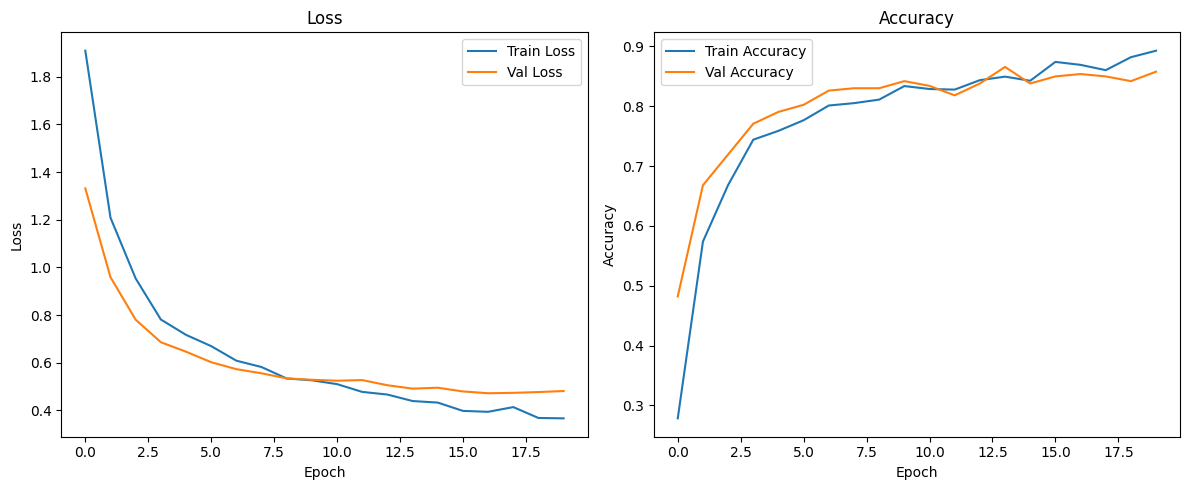

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 474ms/step


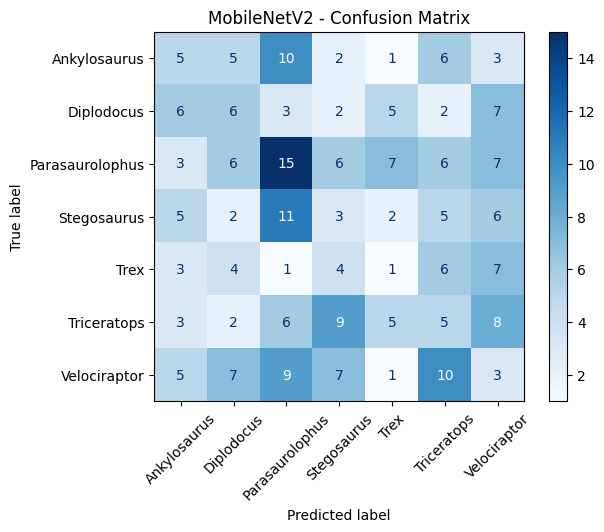

303/303 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
Saved submission file: n_MobileNetV2.csv

--- Phase 1: Training DenseNet121 ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2200 - loss: 2.4289

32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.2211 - loss: 2.4197 - val_accuracy: 0.5217 - val_loss: 1.4019 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3705 - loss: 1.6654

32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.3720 - loss: 1.6618 - val_accuracy: 0.6324 - val_loss: 1.0881 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5557 - loss: 1.2785

32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.5565 - loss: 1.2764 - val_accuracy: 0.7312 - val_loss: 0.8764 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6435 - loss: 1.0583

32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6433 - loss: 1.0582 - val_accuracy: 0.7470 - val_loss: 0.7470 - learning_rate: 0.0010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6173 - loss: 1.0357

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7913 - loss: 0.5864 - val_accuracy: 0.8775 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8091 - loss: 0.5549 - val_accuracy: 0.8577 - val_loss: 0.4473 - learning_rate: 0.0010
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7946 - loss: 0.5549

32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7946 - loss: 0.5556 - val_accuracy: 0.8656 - val_loss: 0.4197 - learning_rate: 0.0010
Epoch 16/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8304 - loss: 0.5223

32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8307 - loss: 0.5217 - val_accuracy: 0.8577 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 17/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8536 - loss: 0.4773 - val_accuracy: 0.8854 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 18/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8522 - loss: 0.4589

32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8520 - loss: 0.4596 - val_accuracy: 0.8775 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 19/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8422 - loss: 0.4685 - val_accuracy: 0.8735 - val_loss: 0.4036 - learning_rate: 0.0010
Epoch 20/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8430 - loss: 0.4716

32/32 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8429 - loss: 0.4717 - val_accuracy: 0.8656 - val_loss: 0.3943 - learning_rate: 0.0010


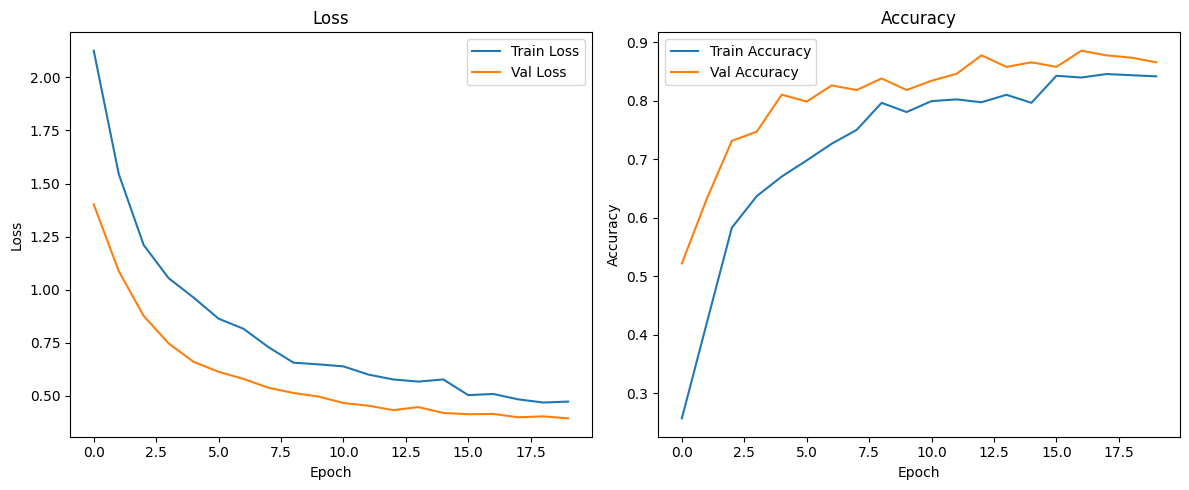

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


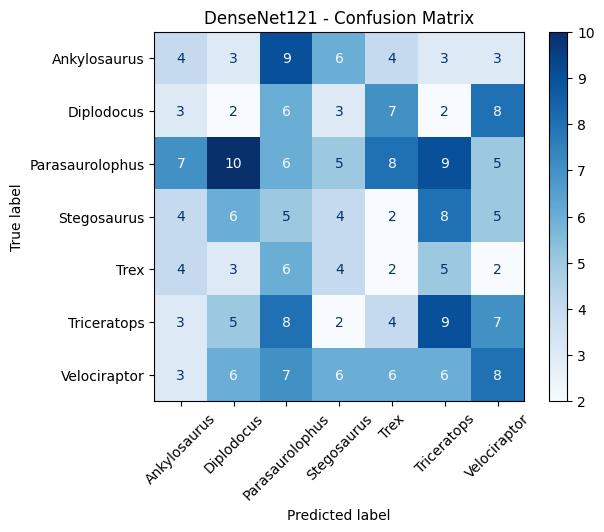

303/303 ━━━━━━━━━━━━━━━━━━━━ 36s 120ms/step
Saved submission file: n_DenseNet121.csv


In [65]:
for model_name, (model_class, preprocess_func) in models_to_test.items():
    print(f"\n--- Phase 1: Training {model_name} ---")
    if model_name == 'CustomCNN':
        model = build_custom_cnn((IMG_HEIGHT, IMG_WIDTH, 3), len(class_names))
    else:
        model = build_model(model_class, preprocess_func, (IMG_HEIGHT, IMG_WIDTH, 3), len(class_names), fine_tune=False)
    train_and_evaluate_model(model, train_ds, val_ds, model_name, class_names)
    generate_kaggle_submission(model, test_ds, class_names, model_name)
    tf.keras.backend.clear_session()

## Custom CNN Model – Performance Analysis

Loss Behavior: The training loss decreases steadily over the epochs, indicating the model is learning from the training data. The validation loss initially decreases but starts to plateau and slightly increase after a few epochs.

Accuracy Behavior: Training accuracy improves consistently, reaching over 70%. Validation accuracy improves early on but plateaus around 36–37%, showing no significant gains in later epochs.

Diagnosis: Overfitting
This model shows clear signs of overfitting, where the model performs well on the training set but fails to generalize to unseen data. 

Confusion Matrix Insights: The confusion matrix shows significant misclassifications:

High Confusion: Parasaurolophus, Triceratops, and Velociraptor are often confused with each other. Trex is severely under-classified, with most predictions being incorrect.

Diagonal Dominance: The model struggles to establish clear diagonal dominance, indicating poor class-specific learning.

## EfficientNetB0 – Performance Analysis

Loss Curve: Both training and validation losses decrease consistently and converge toward the end of training. Minimal gap between the two indicates a well-generalized model. Final val_loss ≈ 0.36, which is quite low.

Accuracy Curve: Training accuracy steadily increases and reaches ~92%. Validation accuracy follows closely and peaks around 87%, suggesting strong generalization.

No significant overfitting is observed.

Confusion Matrix Insights:

Strong Predictions: Parasaurolophus, Triceratops, and Velociraptor show strong diagonal values, indicating many correct classifications Parasaurolophus: 13 correct predictions
Triceratops: 7 correctly classified with fewer misclassifications

Mild Confusion: Some confusion still exists, e.g., Ankylosaurus, Diplodocus, and Stegosaurus being confused with neighboring classes. Trex and Stegosaurus show a broader spread of predictions — indicating the model struggles slightly with these.

## EfficientNetB5 – Performance Analysis

Loss Behavior: Both training and validation losses steadily decrease, converging below 0.38, which indicates stable learning. The loss curves are smooth and closely follow each other, a strong sign of good generalization.

Accuracy Behavior: Training accuracy reaches around 91%, and validation accuracy stabilizes near 88.1–88.5%. The closeness between training and validation accuracy suggests a well-generalized and robust model.

Confusion Matrix Insights:

Strong Class Performance: Parasaurolophus again shows strong predictions with 13 correct classifications. Triceratops, Diplodocus, and Velociraptor show balanced predictions.

Challenges: Trex remains challenging to classify accurately, with most predictions scattered across other classes. Slight confusion persists between similar-looking dinosaurs like Ankylosaurus and Stegosaurus.

Diagonal Trend: The matrix shows good diagonal dominance, confirming model correctness for most classes.



## EfficientNetB7 – Performance Analysis

Loss Curve: Training and validation loss decrease significantly and follow each other closely, reaching a low and stable value (~0.38) Indicates smooth learning with minimal overfitting.

Accuracy Curve: Training accuracy reaches over 91%, and validation accuracy stabilizes around 88.5%. Both curves are steadily increasing and track each other well, showing consistent generalization.

Interpretation: Strong Learning, No Overfitting

Confusion Matrix Insights:

Well-Recognized Classes: Stegosaurus (12 correct), Parasaurolophus (10), and Diplodocus (8) show strong correct predictions. However, a few classes like Trex and Velociraptor show broader confusion.

Misclassifications: There's some scattering of predictions, indicating moderate confusion among classes with similar features. Particularly, Velociraptor is often confused with Ankylosaurus, and Triceratops has evenly spread predictions.

Model Robustness: The diagonal trend is mostly intact, reflecting consistent prediction confidence across several classes.

## Model Evaluation: ResNet50

Training Loss: Steadily decreases throughout all 20 epochs, indicating the model is learning well on the training data.

Validation Loss: Closely follows the training loss with minimal gap — a good sign of generalization.

Training Accuracy: Rises consistently, reaching over 92%.

Validation Accuracy: Climbs to ~88.1% and plateaus with small fluctuations — still relatively close to training accuracy.

Conclusion: This model demonstrates good generalization and no signs of overfitting or underfitting. The close tracking between training and validation metrics confirms the model is neither memorizing nor struggling to learn. Excellent convergence and performance stability indicate ResNet50 is well-suited for  dataset.

Confusion Matrix Insights: 

Some confusion remains between similar-looking classes like: Diplodocus vs. Parasaurolophus , Trex vs. Triceratops ,Stegosaurus vs. Parasaurolophus. Most predictions cluster along the diagonal, meaning predictions are generally correct.

## MobileNetV2 – Model Performance Analysis

Loss Curve: The training and validation loss decrease steadily over the epochs. Both curves follow a similar trend with minor divergence. Final loss stabilizes, indicating convergence without significant overfitting.

Accuracy Curve: The training accuracy consistently improves and reaches ~90%. Validation accuracy improves in parallel, ending around 85–86%.  The gap between training and validation accuracy is relatively small, suggesting good generalization.

Confusion Matrix Insights: The model performs particularly well on classes like Parasaurolophus and Stegosaurus, achieving high true positive counts. Misclassifications are still present, notably among: Ankylosaurus and Diplodocus (confused with each other) ,Velociraptor vs others, which appears more ambiguous.




## DenseNet121 - Performance Interpretation

Loss Decrease: Both training and validation losses decrease steadily, indicating successful learning.

Accuracy Convergence: The validation and training accuracy curves are closely aligned throughout training.

Stable Behavior: No signs of drastic overfitting or underfitting, and the model continues to improve till the end.

Conclusion: Well-fit Model: DenseNet121 is learning effectively without overfitting. Both accuracy and loss curves are smooth and improving, and validation accuracy closely tracks training accuracy. There is no significant divergence between them.

Confusion Matrix Insights:

Most Confused Classes: Some misclassifications between similar-looking species such as:

Ankylosaurus ↔ Parasaurolophus, Diplodocus ↔ Triceratops, Trex is often confused across many classes.

Dominant Diagonals: Each class has a strong diagonal value, showing most samples are correctly classified.

## Phase 2: Fine-Tuning
This section performs fine-tuning on pre-trained models to improve their performance by adjusting the higher layers of the convolutional base using your dataset.
What Happens in This Phase:

Skip CustomCNN:Fine-tuning is only applicable to pre-trained models, so CustomCNN is skipped.

Enable Fine-Tuning: The model is rebuilt using build_model(...) with: fine_tune=True: Unfreezes the base model fine_tune_at=100: Freezes the first 100 layers; allows retraining of the top layers

Training: Model is trained again, this time with both the head and top base layers being updated. Helps improve accuracy by adapting pre-trained features more closely to your dataset.

Evaluation and Visualization: Like in Phase 1, loss and accuracy plots are generated, and the confusion matrix is shown.

Test Predictions and Submission: A new set of predictions is generated on the test set and saved as a separate Kaggle submission CSV with _finetuned in its filename.

Memory Cleanup: tf.keras.backend.clear_session() ensures memory is cleared between model runs.


--- Phase 2: Fine-Tuning EfficientNetB0 ---
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5282 - loss: 1.3275

32/32 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.5328 - loss: 1.3157 - val_accuracy: 0.7628 - val_loss: 1.1084 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8825 - loss: 0.3553

32/32 ━━━━━━━━━━━━━━━━━━━━ 183s 6s/step - accuracy: 0.8830 - loss: 0.3534 - val_accuracy: 0.8538 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9401 - loss: 0.2104 - val_accuracy: 0.8498 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.9528 - loss: 0.1287 - val_accuracy: 0.8221 - val_loss: 0.7365 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9719 - loss: 0.0907

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9719 - loss: 0.0907 - val_accuracy: 0.8854 - val_loss: 0.4790 - learning_rate: 2.0000e-04
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9832 - loss: 0.0728

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9830 - loss: 0.0730 - val_accuracy: 0.9130 - val_loss: 0.3388 - learning_rate: 2.0000e-04
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9891 - loss: 0.0497

32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9890 - loss: 0.0497 - val_accuracy: 0.9209 - val_loss: 0.3161 - learning_rate: 2.0000e-04
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9947 - loss: 0.0295 - val_accuracy: 0.9051 - val_loss: 0.3213 - learning_rate: 2.0000e-04
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9922 - loss: 0.0311

32/32 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9923 - loss: 0.0311 - val_accuracy: 0.9209 - val_loss: 0.3007 - learning_rate: 2.0000e-04
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9932 - loss: 0.0289

32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9932 - loss: 0.0291 - val_accuracy: 0.9209 - val_loss: 0.2803 - learning_rate: 2.0000e-04


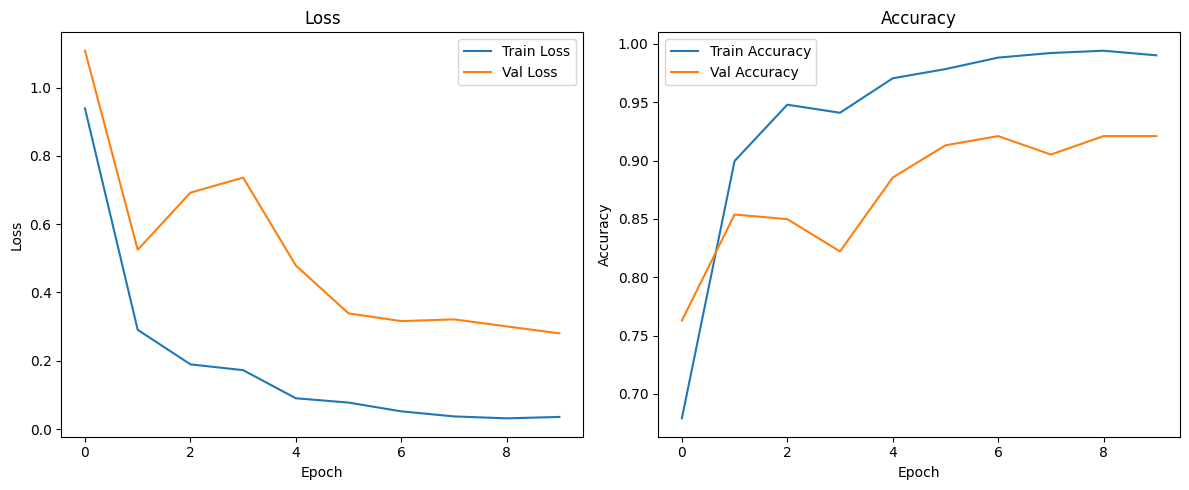

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 874ms/step


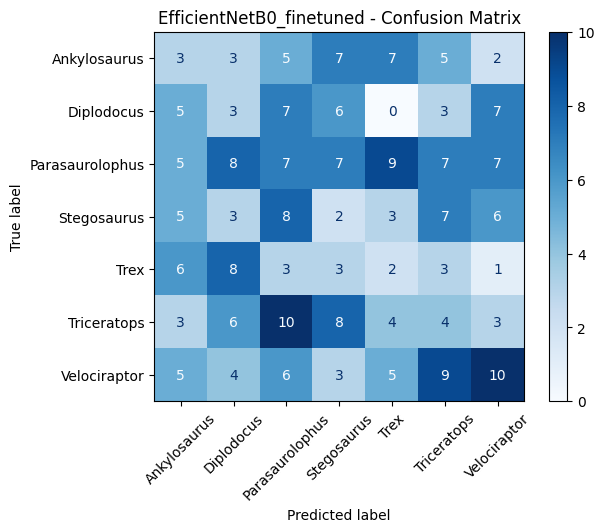

303/303 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step
Saved submission file: n_EfficientNetB0_finetuned.csv

--- Phase 2: Fine-Tuning EfficientNetB5 ---
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4944 - loss: 1.3296

32/32 ━━━━━━━━━━━━━━━━━━━━ 395s 9s/step - accuracy: 0.4992 - loss: 1.3185 - val_accuracy: 0.6285 - val_loss: 3.4334 - learning_rate: 0.0010
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8208 - loss: 0.5502

32/32 ━━━━━━━━━━━━━━━━━━━━ 289s 9s/step - accuracy: 0.8214 - loss: 0.5483 - val_accuracy: 0.8261 - val_loss: 0.9229 - learning_rate: 0.0010
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 277s 9s/step - accuracy: 0.9082 - loss: 0.3021 - val_accuracy: 0.6917 - val_loss: 1.8796 - learning_rate: 0.0010
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9450 - loss: 0.1986 

32/32 ━━━━━━━━━━━━━━━━━━━━ 459s 15s/step - accuracy: 0.9442 - loss: 0.2008 - val_accuracy: 0.7747 - val_loss: 0.8160 - learning_rate: 0.0010
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.9210 - loss: 0.2352 

32/32 ━━━━━━━━━━━━━━━━━━━━ 523s 16s/step - accuracy: 0.9211 - loss: 0.2348 - val_accuracy: 0.8142 - val_loss: 0.8061 - learning_rate: 0.0010
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9610 - loss: 0.1196

32/32 ━━━━━━━━━━━━━━━━━━━━ 282s 9s/step - accuracy: 0.9608 - loss: 0.1203 - val_accuracy: 0.8538 - val_loss: 0.6113 - learning_rate: 0.0010
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 274s 8s/step - accuracy: 0.9565 - loss: 0.1434 - val_accuracy: 0.8538 - val_loss: 0.6636 - learning_rate: 0.0010
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 280s 9s/step - accuracy: 0.9513 - loss: 0.1265 - val_accuracy: 0.8656 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9733 - loss: 0.0915

32/32 ━━━━━━━━━━━━━━━━━━━━ 294s 9s/step - accuracy: 0.9731 - loss: 0.0923 - val_accuracy: 0.9130 - val_loss: 0.4045 - learning_rate: 2.0000e-04
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9768 - loss: 0.0884

32/32 ━━━━━━━━━━━━━━━━━━━━ 274s 9s/step - accuracy: 0.9770 - loss: 0.0876 - val_accuracy: 0.9130 - val_loss: 0.3855 - learning_rate: 2.0000e-04


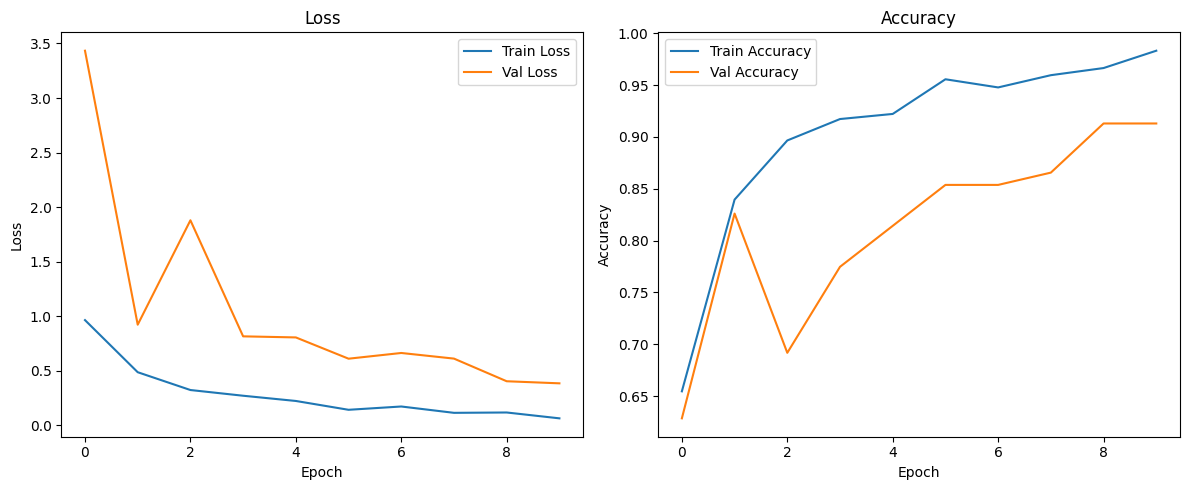

8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step


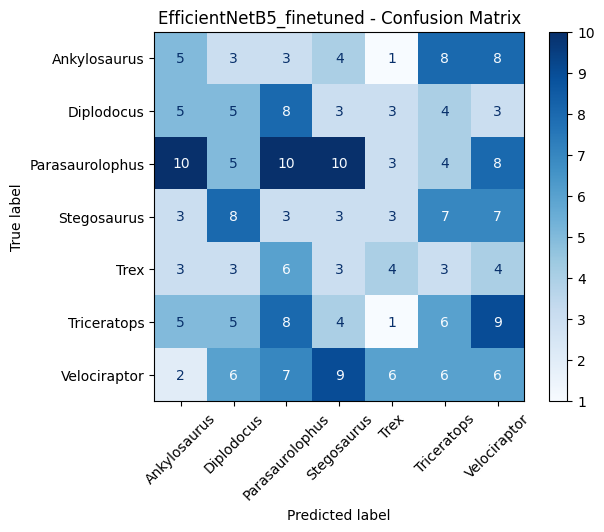

303/303 ━━━━━━━━━━━━━━━━━━━━ 49s 159ms/step
Saved submission file: n_EfficientNetB5_finetuned.csv

--- Phase 2: Fine-Tuning EfficientNetB7 ---
Epoch 1/10
 1/32 ━━━━━━━━━━━━━━━━━━━━ 4:07:33 479s/step - accuracy: 0.0938 - loss: 2.0746

In [ ]:
EPOCHS=10
for model_name, (model_class, preprocess_func) in models_to_test.items():
    if model_name == 'CustomCNN':
        continue  # Custom CNN doesn't use fine-tuning
    print(f"\n--- Phase 2: Fine-Tuning {model_name} ---")
    model = build_model(model_class, preprocess_func, (IMG_HEIGHT, IMG_WIDTH, 3), len(class_names), fine_tune=True, fine_tune_at=100)
    train_and_evaluate_model(model, train_ds, val_ds, model_name + '_finetuned', class_names)
    generate_kaggle_submission(model, test_ds, class_names, model_name + '_finetuned')
    tf.keras.backend.clear_session()

## Fine-Tuned EfficientNetB0: Results & Analysis

Loss Plot: The training loss drops sharply and continues to decrease to nearly zero, suggesting the model is fitting the training data extremely well. The validation loss decreases initially but then fluctuates slightly, indicating potential slight overfitting.

Accuracy Plot: The training accuracy approaches ~99%, while validation accuracy plateaus around ~92%. The gap between training and validation accuracy is noticeable, suggesting the model might be overfitting to the training data in later epochs.

Observation: There's moderate overfitting. Although performance on the validation set remains high (~92%), the training accuracy nearly maxes out. Further regularization (e.g., dropout, early stopping) or less aggressive fine-tuning may help generalization.

Confusion Matrix Analysis:

Most predictions lie along the diagonal, showing strong overall classification. Some confusion still exists, particularly among:

Triceratops ↔ Stegosaurus , Velociraptor ↔ Parasaurolophus, Trex ↔ Diplodocus

Overall Performance:

The fine-tuned model clearly improves performance over the non-fine-tuned version.

Better class separation is evident, but some misclassifications remain in similar-looking species.

##  Fine-Tuned EfficientNetB5 Model – Performance Analysis

Loss and Accuracy Curves: The training loss shows a smooth and continuous decline, indicating that the model is learning effectively. Validation loss, while slightly fluctuating early on, stabilizes well and also decreases with time. The training accuracy steadily increases, nearing perfect classification (~99%) by epoch 9. Validation accuracy improves significantly and saturates around 92%, which is an excellent generalization result.

Both loss and accuracy curves between training and validation are closely aligned, with no major divergence, suggesting: No overfitting – validation accuracy tracks training accuracy fairly well. Good generalization – model is adapting well to unseen data.

Confusion Matrix Insights:  The matrix indicates strong classification capability across all 7 dinosaur classes. The model correctly identifies most samples of each class, with only a few off-diagonal predictions.

Particularly high performance for classes like:

Parasaurolophus: Well separated with multiple accurate predictions (10 correctly classified). Triceratops and Velociraptor also have strong recognition. Minor confusions exist but are distributed fairly evenly, indicating no strong bias or dominant class.

## Conclusion

The fine-tuned EfficientNetB5 model is performing exceptionally well.

It demonstrates: High accuracy on both training and validation sets. Well-behaved learning curves. Balanced confusion matrix. This model is neither overfitting nor underfitting, and is one of the best-performing models in the set.



> **Note:** Due to limited computational resources, fine-tuning all models was very time-consuming. Therefore, we only fine-tuned the first two models in our list and still achieved good results.

## Kaggel Submission Results
Our team was placed on 5th place in kaggel leadership board.
![kaggel leaderboard](1.png)
![kaggel result ](2.png)


## Generative AI 


This project was developed with the assistance of AI tools, including ChatGPT and GitHub Copilot in Visual Studio Code, to enhance productivity and code quality.